In [3]:
import pandas as pd

# Cargar data preprocesada:
data_p = pd.read_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1')

data_p.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,2014.0,1.0,201401.0,Concesionado,22PE5NACS1,San Martín
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,2014.0,1.0,201401.0,Concesionado,04PE1SCAM1,Arequipa
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,2014.0,1.0,201401.0,Concesionado,21PE3SCRO1,Puno
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,2014.0,1.0,201401.0,Concesionado,12PE3NCRA1,Junín
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,2014.0,1.0,201401.0,Concesionado,08PE3SCSC1,Cusco


In [23]:
data_p.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO', 'ADMINIST', 'CODIGO_PEAJE',
       'DEPARTAMENTO'],
      dtype='object')

In [24]:
# Separamos las el dataset de entrenamiento y validacion
from sklearn.model_selection import train_test_split

targets = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E']

X = data_p.drop(targets, axis=1)
y = data_p[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
df_num = X_test.select_dtypes(include=['number', 'int', 'float'])
df_cat = X_test.select_dtypes(include=['object'])

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), list(df_num.columns)),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), list(df_cat.columns)),
    ])

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

for t in targets:
    y_train[t] = y_train[t].apply(np.log1p)
    y_test[t] = y_test[t].apply(np.log1p)

In [ ]:
# Entrenamiento de los modelos
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Pipeline base
pipe_model = Pipeline(
    ('scaler', 'Passthrough'),
    ('model', LinearRegression())
)

# Generamos los parametros a probar en paramgrid
param_grid = [
    {
        'model': [LinearRegression()],
        'scaler' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [XGBRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [SVR()],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'scaler' : [StandardScaler(), MinMaxScaler()]
    }
]


In [3]:
data_p.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO', 'ADMINIST_No concesionado',
       'DEPARTAMENTO_Apurimac', 'DEPARTAMENTO_Apurímac',
       'DEPARTAMENTO_Arequipa', 'DEPARTAMENTO_Ayacucho',
       'DEPARTAMENTO_Cajamarca', 'DEPARTAMENTO_Cusco', 'DEPARTAMENTO_Huánuco',
       'DEPARTAMENTO_Ica', 'DEPARTAMENTO_Junín', 'DEPARTAMENTO_La Libertad',
       'DEPARTAMENTO_Lambayeque', 'DEPARTAMENTO_Lima',
       'DEPARTAMENTO_Madre de Dios', 'DEPARTAMENTO_Moquegua',
       'DEPARTAMENTO_Piura', 'DEPARTAMENTO_Puno', 'DEPARTAMENTO_San Martin',
       'DEPARTAMENTO_San Martín', 'DEPARTAMENTO_Tacna', 'DEPARTAMENTO_Tumbes',
       'DEPARTAMENTO_Áncash', 'CODIGO_PEAJE', 'CUARENTENA'],
      dtype='object')

In [4]:
data_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   VEH_LIGEROS_TAR_DIF         10386 non-null  float64
 1   VEH_LIGEROS_AUTOMOVILES     10386 non-null  float64
 2   VEH_PESADOS__2E             10386 non-null  float64
 3   VEH_PESADOS_3E              10386 non-null  float64
 4   VEH_PESADOS_4E              10386 non-null  float64
 5   VEH_PESADOS_5E              10386 non-null  float64
 6   VEH_PESADOS_6E              10386 non-null  float64
 7   VEH_PESADOS_7E              10386 non-null  float64
 8   ANIO                        10386 non-null  float64
 9   MES                         10386 non-null  float64
 10  PERIODO                     10386 non-null  float64
 11  ADMINIST_No concesionado    10386 non-null  float64
 12  DEPARTAMENTO_Apurimac       10386 non-null  float64
 13  DEPARTAMENTO_Apurímac       103

In [5]:
data_p['PERIODO'] = data_p['PERIODO'].fillna(201301).apply(int)

data_p = data_p[data_p['PERIODO'] != 201301]

In [6]:
data_p['CODIGO_PEAJE'].unique()

array(['22PE5NACS1', '04PE1SCAM1', '21PE3SCRO1', '12PE3NCRA1',
       '08PE3SCSC1', '13PE1NCMA1', '15PE1SCLA1', '20PE1NJCLS1',
       '13PE08CDS1', '15PE22CCA1', '20PE1NCBA1', '14PE04BOLS1',
       '04PE1SEFS1', '15PE1NEPS1', '15PE1NFZA1', '02PE1NHUY1',
       '11PE1SICA1', '18PE36ILO1', '11PE1SJAY1', '20PE02ALLA1',
       '21PE34BMNI1', '11PE30MNA1', '04PE34MRI1', '13PE10AMEO1',
       '14PE1NJMOC1', '18PE1SMTV1', '14PE1NMRE1', '22PE5NMYB1',
       '13PE1NPGA1', '20PE02PAI1', '18PE36APCL1', '05PE30APGR1',
       '03PE30APPR1', '04PE34APTI1', '01PE08CPRS1', '03PE30APRH1',
       '20PE1NPSA1', '17PE30CPNN1', '06PE3NPPU1', '22PE5NBPGO1',
       '12PE3SQLA1', '21PE34BSGB1', '17PE30CSLZ1', '21PE34ASLA1',
       '15PE1NASPY1', '23PE1STMS1', '04PE34AVYO1', '17PE30CUPO1',
       '01PE5NUTB1', '15PE1NVPY1', '02PE1NVSQ1', '13PE1NVIR1',
       '08PE3SACS1', '04PE1SATI1', '21PE3SAYV1', '24PE1NCCS1',
       '02PE3NCTC1', '12PE3SHUO1', '12PE22BCHO1', '14PE06ACUC1',
       '20PE1NTYL1', '21PE3SILV1'

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

peaje = '20PE1NJCLS1'

data_f = data_p[data_p['CODIGO_PEAJE'] == peaje]

data_f.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,...,DEPARTAMENTO_Moquegua,DEPARTAMENTO_Piura,DEPARTAMENTO_Puno,DEPARTAMENTO_San Martin,DEPARTAMENTO_San Martín,DEPARTAMENTO_Tacna,DEPARTAMENTO_Tumbes,DEPARTAMENTO_Áncash,CODIGO_PEAJE,CUARENTENA
7,7.580189,10.417029,9.258464,8.498418,5.225747,6.274762,8.381373,179.0,2014.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20PE1NJCLS1,0
84,7.890208,10.256255,9.041567,8.287025,5.283204,6.150603,8.443116,85.0,2014.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20PE1NJCLS1,0
161,7.916078,10.308586,8.992433,8.103494,5.023881,6.059123,8.330623,17.0,2014.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20PE1NJCLS1,0
238,7.813187,10.296003,8.996652,8.003363,4.859812,5.659482,8.208764,60.0,2014.0,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20PE1NJCLS1,0
315,7.867489,10.369671,9.106756,8.080237,4.820282,5.942799,8.430763,38.0,2014.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,20PE1NJCLS1,0


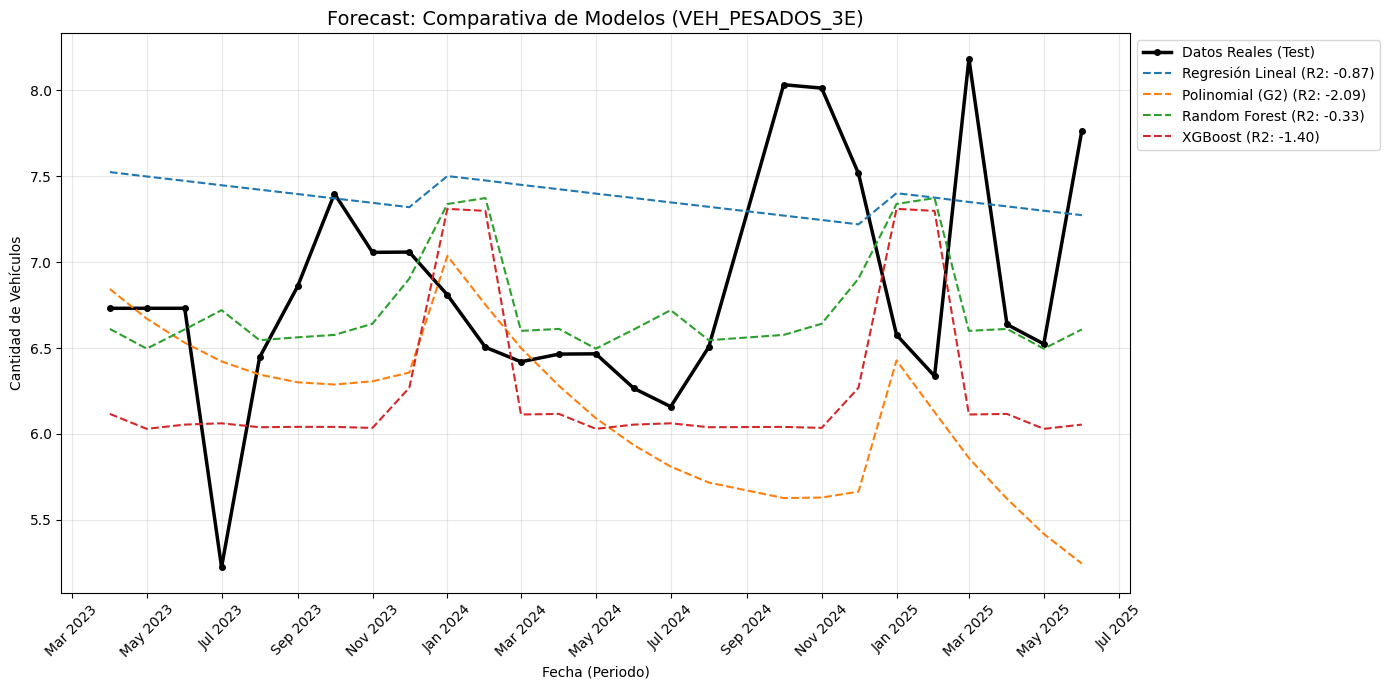


--- TABLA DE INDICADORES ---
          Modelo      MSE  R2 Score
   Random Forest 0.564115 -0.328932
Regresión Lineal 0.794864 -0.872526
         XGBoost 1.019626 -1.402015
 Polinomial (G2) 1.313629 -2.094623


In [8]:
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates

# --- 1. PREPARACIÓN DEL ÍNDICE TEMPORAL ---
df = data_f.copy()

# Convertimos '202501.0' (float) -> 202501 (int) -> '202501' (str)
# Luego a datetime usando el formato de Año y Mes (%Y%m)
df['PERIODO'] = pd.to_datetime(df['PERIODO'].astype(int).astype(str), format='%Y%m')

# Lo fijamos como Índice y ordenamos
df = df.set_index('PERIODO')
df = df.sort_index()

# --- 2. DEFINICIÓN DE VARIABLES ---
features = ['ANIO', 'MES', 'CUARENTENA']
target = 'VEH_PESADOS_3E'

X = df[features]
y = df[target]

# --- 3. DIVISIÓN TRAIN / TEST ---
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 4. NORMALIZACIÓN (SCALING) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- 5. DEFINICIÓN DE MODELOS ---
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Polinomial (G2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

# --- 6. ENTRENAMIENTO Y EVALUACIÓN ---
resultados = []
plt.figure(figsize=(14, 7))

# Graficamos DATOS REALES
plt.plot(y_test.index, y_test, label='Datos Reales (Test)', color='black', linewidth=2.5, marker='o', markersize=4)

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "R2 Score": r2
    })
    
    # Graficar la predicción
    plt.plot(y_test.index, y_pred, label=f'{nombre} (R2: {r2:.2f})', linestyle='--')

# --- 7. FORMATEO DEL GRÁFICO ---
plt.title(f"Forecast: Comparativa de Modelos ({target})", fontsize=14)
plt.xlabel("Fecha (Periodo)")
plt.ylabel("Cantidad de Vehículos")

# Mejorar la lectura de las fechas en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Una marca cada 2 meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Formato: Ene 2025
plt.xticks(rotation=45)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Leyenda fuera del gráfico para no tapar
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. RESULTADOS FINALES ---
df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Score", ascending=False)
print("\n--- TABLA DE INDICADORES ---")
print(df_resultados.to_string(index=False))

In [9]:
data_f = data_p[(data_p['CODIGO_PEAJE'] == peaje) & (data_p['CUARENTENA'] != 1)]

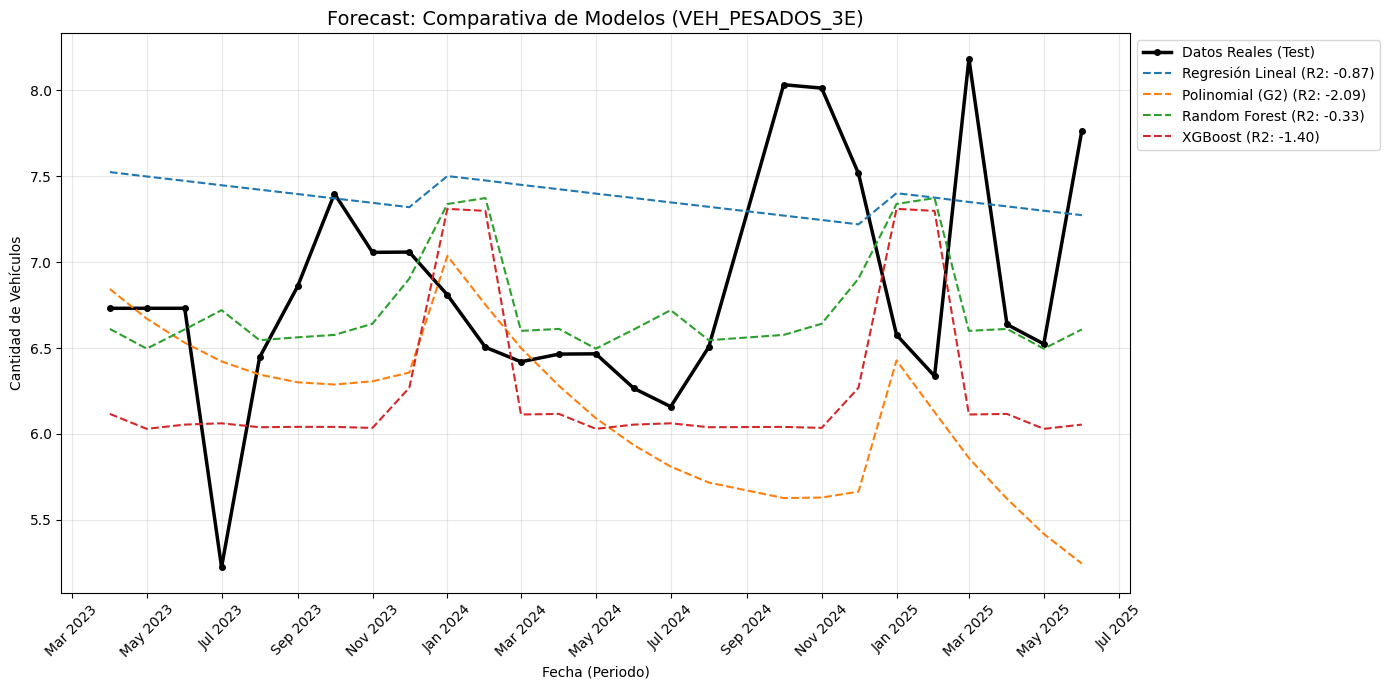


--- TABLA DE INDICADORES ---
          Modelo      MSE  R2 Score
   Random Forest 0.564115 -0.328932
Regresión Lineal 0.794864 -0.872526
         XGBoost 1.019626 -1.402015
 Polinomial (G2) 1.313629 -2.094623


In [10]:
# --- 1. PREPARACIÓN DEL ÍNDICE TEMPORAL ---
df = data_f.copy()

# Convertimos '202501.0' (float) -> 202501 (int) -> '202501' (str)
# Luego a datetime usando el formato de Año y Mes (%Y%m)
df['PERIODO'] = pd.to_datetime(df['PERIODO'].astype(int).astype(str), format='%Y%m')

# Lo fijamos como Índice y ordenamos
df = df.set_index('PERIODO')
df = df.sort_index()

# --- 2. DEFINICIÓN DE VARIABLES ---
#features = ['ANIO', 'MES', 'CUARENTENA']
#target = 'VEH_LIGEROS_TOTAL'

X = df[features]
y = df[target]

# --- 3. DIVISIÓN TRAIN / TEST ---
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 4. NORMALIZACIÓN (SCALING) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- 5. DEFINICIÓN DE MODELOS ---
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Polinomial (G2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

# --- 6. ENTRENAMIENTO Y EVALUACIÓN ---
resultados = []
plt.figure(figsize=(14, 7))

# Graficamos DATOS REALES
plt.plot(y_test.index, y_test, label='Datos Reales (Test)', color='black', linewidth=2.5, marker='o', markersize=4)

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "R2 Score": r2
    })
    
    # Graficar la predicción
    plt.plot(y_test.index, y_pred, label=f'{nombre} (R2: {r2:.2f})', linestyle='--')

# --- 7. FORMATEO DEL GRÁFICO ---
plt.title(f"Forecast: Comparativa de Modelos ({target})", fontsize=14)
plt.xlabel("Fecha (Periodo)")
plt.ylabel("Cantidad de Vehículos")

# Mejorar la lectura de las fechas en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Una marca cada 2 meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Formato: Ene 2025
plt.xticks(rotation=45)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Leyenda fuera del gráfico para no tapar
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. RESULTADOS FINALES ---
df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Score", ascending=False)
print("\n--- TABLA DE INDICADORES ---")
print(df_resultados.to_string(index=False))